# Analiza podatkov o knjigah

V tej datoteki analiziram podatke, pridobljene s programom 
`zajem_podatkov.py`.

Osnovni podatki vsebujejo informacije o knjigah iz seznama Goodreads:
- naslov knjige,
- avtor,
- ocena,
- povezava do knjige.

Najprej izvedem splošno analizo vseh zajetih knjig, nato pa še 
poglobljeno analizo izbranih 50 knjig, kjer uporabim dodatne podatke,
pridobljene s posameznih strani knjig.

## 1. Splošna analiza vseh knjig

V prvem delu analiziram celoten nabor podatkov, ki vsebuje vse knjige,
zajete s seznama Goodreads.

Najprej podatke uvozim v pandas DataFrame in preverim osnovno strukturo
podatkov. Nato očistim podatke o ocenah, saj so bile prvotno shranjene
kot besedilo skupaj z dodatnimi informacijami o številu ocen.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
print("Trenutno sem v:", os.getcwd())

print("V mapi podatki vidim:")
print(os.listdir("podatki"))

Trenutno sem v: /Users/zarjakotlusekpavcic/projektna_naloga_koncna
V mapi podatki vidim:
['knjige_podrobno.csv', 'dodatni_podatki.csv']


In [3]:
import pandas as pd
import os

datoteka = os.path.join(
    "podatki",
    "knjige_podrobno.csv"
)

df = pd.read_csv(
    datoteka,
    encoding="utf-8"
)

df.head()

,naslov,avtor,ocena_raw,povezava
0,To Kill a Mockingbird,Harper Lee,"4.26 avg rating — 7,072,620 ratings",https://www.goodreads.com/book/show/2657.To_Ki...
1,1984,George Orwell,"4.20 avg rating — 5,696,598 ratings",https://www.goodreads.com/book/show/5470.1984
2,Pride and Prejudice,Jane Austen,"4.30 avg rating — 4,966,466 ratings",https://www.goodreads.com/book/show/1885.Pride...
3,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling,"4.47 avg rating — 11,722,414 ratings",https://www.goodreads.com/book/show/3.Harry_Po...
4,The Great Gatsby,F. Scott Fitzgerald,"3.93 avg rating — 6,094,371 ratings",https://www.goodreads.com/book/show/4671.The_G...


## Ali dolžina naslova vpliva na oceno?

Preverila sem, ali obstaja povezava med dolžino naslova
in povprečno oceno knjige.

Za vsako dolžino naslova sem izračunala povprečno oceno.

In [4]:
import pandas as pd
import os

csv_pot = os.path.join(
    "podatki",
    "knjige_podrobno.csv"
)

df = pd.read_csv(
    csv_pot,
    encoding="utf-8"
)

df.head()
# Tukaj ne zajemam več podatkov s spletne strani.
# To je namenjeno samo analizi.
# Program zajem_podatkov.py je že ustvaril CSV datoteko,
# zato jo sedaj samo preberem v pandas DataFrame.




,naslov,avtor,ocena_raw,povezava
0,To Kill a Mockingbird,Harper Lee,"4.26 avg rating — 7,072,620 ratings",https://www.goodreads.com/book/show/2657.To_Ki...
1,1984,George Orwell,"4.20 avg rating — 5,696,598 ratings",https://www.goodreads.com/book/show/5470.1984
2,Pride and Prejudice,Jane Austen,"4.30 avg rating — 4,966,466 ratings",https://www.goodreads.com/book/show/1885.Pride...
3,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling,"4.47 avg rating — 11,722,414 ratings",https://www.goodreads.com/book/show/3.Harry_Po...
4,The Great Gatsby,F. Scott Fitzgerald,"3.93 avg rating — 6,094,371 ratings",https://www.goodreads.com/book/show/4671.The_G...


## Analiza avtorjev

Avtorje sem primerjala glede na:
- število knjig v seznamu,
- povprečno oceno njihovih knjig.

Upoštevala sem samo avtorje z vsaj tremi knjigami,
da rezultati niso odvisni od posameznih primerov.

In [5]:
df.info()
df.describe()

# S funkcijo info() preverim strukturo podatkov:
# koliko vrstic imam, katere stolpce in ali so manjkajoče vrednosti.

# describe() pa poda osnovne statistične podatke
# za numerične stolpce.

<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   naslov     1021 non-null   str  
 1   avtor      1021 non-null   str  
 2   ocena_raw  1021 non-null   str  
 3   povezava   1021 non-null   str  
dtypes: str(4)
memory usage: 32.0 KB


,naslov,avtor,ocena_raw,povezava
count,1021,1021,1021,1021
unique,1020,689,1020,1021
top,2062: A Future Vision,Charles Dickens,4.94 avg rating — 93 ratings,https://www.goodreads.com/book/show/2657.To_Ki...
freq,2,9,2,1


In [6]:
df["ocena_cista"] = (
    df["ocena_raw"]
    .str.extract(r"(\d\.\d+)")
    .astype(float)
)

df["ocena_cista"].head()

0    4.26
1    4.20
2    4.30
3    4.47
4    3.93
Name: ocena_cista, dtype: float64

In [7]:
print(
    f"Povprečna ocena vseh knjig je: "
    f"{df['ocena_cista'].mean():.2f}"
)

Povprečna ocena vseh knjig je: 3.87


## Porazdelitev ocen knjig

Najprej sem preverila, kako so razporejene ocene knjig.
Za prikaz sem uporabila histogram, ki pokaže,
koliko knjig se nahaja v posameznem ocenjevalnem območju.

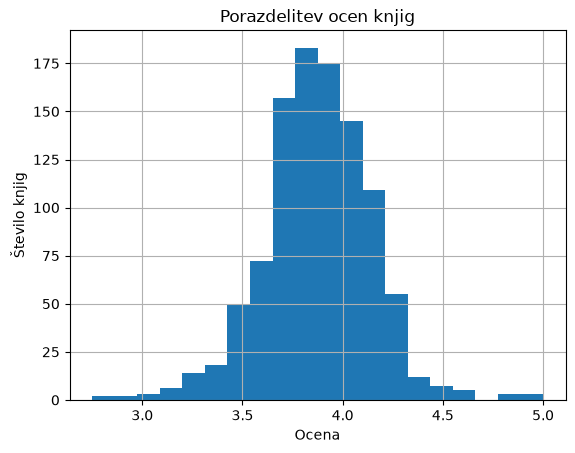

In [8]:
import matplotlib.pyplot as plt

df["ocena_cista"].hist(bins=20)

plt.xlabel("Ocena")
plt.ylabel("Število knjig")
plt.title("Porazdelitev ocen knjig")

plt.show()

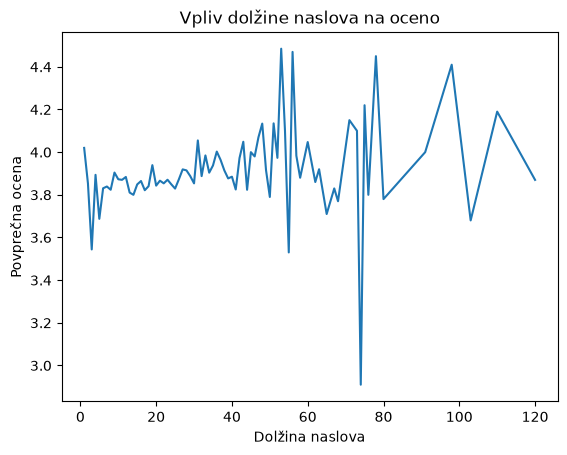

In [9]:
df["dolzina_naslova"] = df["naslov"].str.len()

po_dolzini = (
    df.groupby("dolzina_naslova")["ocena_cista"]
    .mean()
)

po_dolzini.plot(
    title="Vpliv dolžine naslova na oceno"
)

plt.ylabel("Povprečna ocena")
plt.xlabel("Dolžina naslova")

plt.show()

In [10]:
avtorji_stat = df.groupby("avtor").agg({
    "naslov": "count",
    "ocena_cista": "mean"
})

popularni_avtorji = (
    avtorji_stat[
        avtorji_stat["naslov"] >= 3
    ]
)

najboljsi_avtorji = (
    popularni_avtorji
    .sort_values(
        by="ocena_cista",
        ascending=False
    )
)

najboljsi_avtorji.head(10)

,naslov,ocena_cista
avtor,,
Fyodor Dostoevsky,5,4.250000
P.G. Wodehouse,6,4.196667
Ursula K. Le Guin,4,4.170000
Hermann Hesse,3,4.150000
Stephen King(Goodreads Author),3,4.150000
John Steinbeck,3,4.126667
Anthony Trollope,3,4.120000
Hergé,3,4.106667
Ian Rankin(Goodreads Author),3,4.103333


In [11]:
avtorji_stat = df.groupby("avtor").agg({
    "naslov": "count",
    "ocena_cista": "mean"
})

popularni_avtorji = (
    avtorji_stat[
        avtorji_stat["naslov"] >= 3
    ]
)

najboljsi_avtorji = (
    popularni_avtorji
    .sort_values(
        by="ocena_cista",
        ascending=False
    )
)

najboljsi_avtorji.head(10)

,naslov,ocena_cista
avtor,,
Fyodor Dostoevsky,5,4.250000
P.G. Wodehouse,6,4.196667
Ursula K. Le Guin,4,4.170000
Hermann Hesse,3,4.150000
Stephen King(Goodreads Author),3,4.150000
John Steinbeck,3,4.126667
Anthony Trollope,3,4.120000
Hergé,3,4.106667
Ian Rankin(Goodreads Author),3,4.103333


In [12]:
manjkajoce = df["ocena_cista"].isna().sum()

print(
    f"Knjig brez ocene: {manjkajoce}"
)

print(
    f"Odstotek brez ocene: "
    f"{(manjkajoce / len(df))*100:.2f}%"
)

Knjig brez ocene: 0
Odstotek brez ocene: 0.00%


In [ ]:
import os


izhodna_mapa = "rezultati_analize"

os.makedirs(
    izhodna_mapa,
    exist_ok=True
)

print(
    f"Mapa '{izhodna_mapa}' je pripravljena."
)

Mapa 'rezultati_analize' je pripravljena.


In [14]:
# Shranimo statistiko avtorjev.
# V tej datoteki bodo za vsakega avtorja zapisani:
# - število knjig v seznamu,
# - povprečna ocena njegovih knjig.

avtorji_stat.to_csv(
    os.path.join(
        izhodna_mapa,
        "avtorji_statistika.csv"
    ),
    encoding="utf-8"
)

print(
    "Statistika avtorjev je shranjena."
)

Statistika avtorjev je shranjena.


In [15]:
# Shranimo knjige, ki nimajo podatka o oceni.
# To omogoča dodatno preverjanje kakovosti zajetih podatkov.

knjige_brez_ocene = df[
    df["ocena_cista"].isna()
]

knjige_brez_ocene.to_csv(
    os.path.join(
        izhodna_mapa,
        "knjige_brez_ocene.csv"
    ),
    index=False,
    encoding="utf-8"
)

print(
    f"Shranjeno je {len(knjige_brez_ocene)} knjig brez ocene."
)

Shranjeno je 0 knjig brez ocene.


In [16]:
# Izberemo najboljše avtorje glede na povprečno oceno.
# Upoštevamo samo avtorje z vsaj tremi knjigami,
# saj so tako rezultati bolj primerljivi.

top_avtorji = (
    popularni_avtorji
    .sort_values(
        by="ocena_cista",
        ascending=False
    )
    .head(10)
)


top_avtorji.to_csv(
    os.path.join(
        izhodna_mapa,
        "top_avtorji.csv"
    ),
    encoding="utf-8"
)

print(
    "Top 10 avtorjev je shranjenih."
)

Top 10 avtorjev je shranjenih.


In [17]:
# Pregled ustvarjenih datotek

print("Rezultati analize:")

for datoteka in os.listdir(izhodna_mapa):
    print("-", datoteka)

Rezultati analize:
- knjige_brez_ocene.csv
- avtorji_statistika.csv
- top_avtorji.csv


In [18]:
# Osnovni statistični pregled ocen

df[['ocena_cista']].describe()
# Funkcija describe() izračuna osnovne statistične podatke:
# število veljavnih vrednosti, povprečje, standardni odklon,
# najmanjšo in največjo vrednost ter kvartile.

,ocena_cista
count,1021.000000
mean,3.874594
std,0.268387
min,2.750000
25%,3.730000
50%,3.880000
75%,4.040000
max,5.000000


In [19]:
# Izpišemo 10 najbolje ocenjenih knjig

najbolj_ocenjene = (
    df
    .sort_values(
        by="ocena_cista",
        ascending=False
    )
    .head(10)
)

najbolj_ocenjene[
    ["naslov", "avtor", "ocena_cista"]
]

,naslov,avtor,ocena_cista
604,The Metamorphosis of Nick Adams,Gentry Thomason,5.00
412,2062: A Future Vision,Emerson Littlefield(Goodreads Author),4.94
608,2062: A Future Vision,Emerson Littlefield(Goodreads Author),4.94
603,Alla and the Piano – The Russian Tragedy 1912 ...,Morten Kvistgaard(Goodreads Author),4.88
326,The Foundlings and the Fisherman from Tumby,Phillip Leighton-Daly,4.87
602,JACKS FORK: a novel,Chris Orlet(Goodreads Author),4.80
950,The Devil to Pay in the Backlands,João Guimarães Rosa,4.62
229,"Lonesome Dove (Lonesome Dove, #1)",Larry McMurtry,4.60
141,The Complete Maus,Art Spiegelman,4.58
869,Covenant with Death,John Harris,4.57


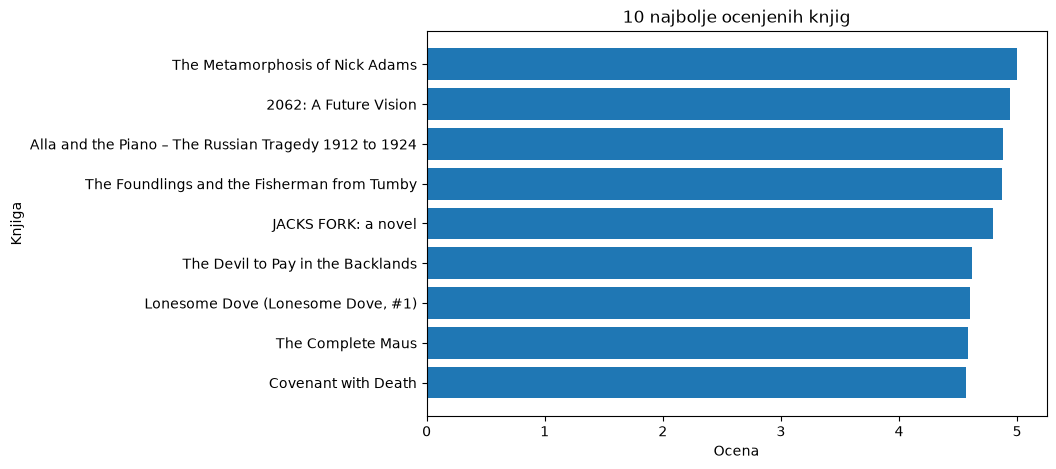

In [20]:
import matplotlib.pyplot as plt

top_knjige = (
    najbolj_ocenjene
    .sort_values(
        by="ocena_cista"
    )
)

plt.figure(figsize=(8,5))

plt.barh(
    top_knjige["naslov"],
    top_knjige["ocena_cista"]
)

plt.xlabel("Ocena")
plt.ylabel("Knjiga")
plt.title("10 najbolje ocenjenih knjig")

plt.show()

In [21]:
# Avtorji z največ knjigami na seznamu

najpogostejsi_avtorji = (
    df["avtor"]
    .value_counts()
    .head(10)
)

najpogostejsi_avtorji

avtor
Charles Dickens      9
Graham Greene        8
Evelyn Waugh         8
Jane Austen          6
Joseph Conrad        6
P.G. Wodehouse       6
Fyodor Dostoevsky    5
Mark Twain           5
Agatha Christie      5
H.G. Wells           5
Name: count, dtype: int64

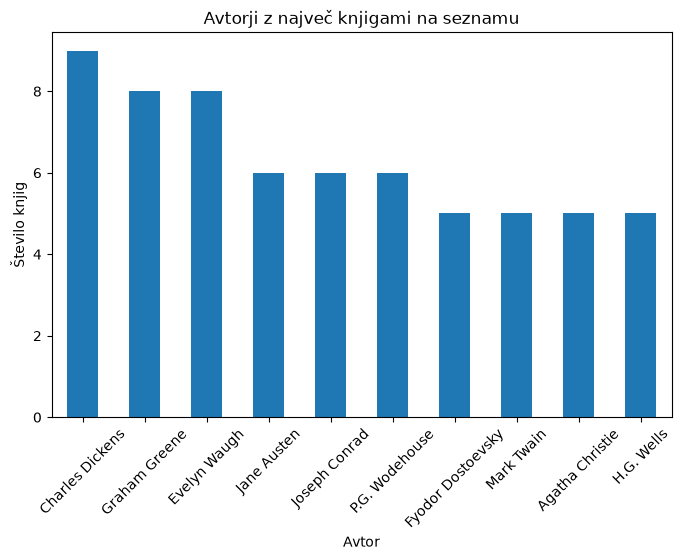

In [22]:
plt.figure(figsize=(8,5))

najpogostejsi_avtorji.plot(
    kind="bar"
)

plt.xlabel("Avtor")
plt.ylabel("Število knjig")
plt.title(
    "Avtorji z največ knjigami na seznamu"
)

plt.xticks(rotation=45)

plt.show()

In [23]:
print("POVZETEK ANALIZE")
print("----------------")

print(
    f"Skupno število knjig: {len(df)}"
)

print(
    f"Povprečna ocena knjig: "
    f"{df['ocena_cista'].mean():.2f}"
)

print(
    f"Število različnih avtorjev: "
    f"{df['avtor'].nunique()}"
)

print(
    f"Najdaljši naslov knjige ima "
    f"{df['dolzina_naslova'].max()} znakov."
)

POVZETEK ANALIZE
----------------
Skupno število knjig: 1021
Povprečna ocena knjig: 3.87
Število različnih avtorjev: 689
Najdaljši naslov knjige ima 120 znakov.


## Zaključek splošne analize

Pri splošni analizi sem ugotovila, da se ocene knjig večinoma nahajajo 
v podobnem območju, zato velike razlike med najbolje in najslabše 
ocenjenimi knjigami niso pogoste.

Analiza avtorjev pokaže, da večje število knjig posameznega avtorja 
še ne pomeni nujno tudi višje povprečne ocene. Prav tako sem preverila,
koliko knjig nima podatka o oceni, saj lahko manjkajoče vrednosti vplivajo
na rezultate analize.

Na podlagi osnovne analize sem dobila splošen pregled strukture podatkov
in značilnosti obravnavanega seznama knjig.

# 2. Poglobljena analiza izbranih knjig

V nadaljevanju analiziram manjši podnabor podatkov.

Za poglobljeno analizo sem uporabila prvih 50 knjig s seznama Goodreads.
Za te knjige program dodatno obišče posamezne spletne strani knjig in
pridobi dodatne informacije.

Namen tega dela analize je pokazati uporabo bolj podrobnega zajema
podatkov, kjer ne analiziram samo osnovnih informacij iz seznama, ampak
tudi podatke, povezane s posamezno knjigo.

In [24]:
import pandas as pd

dodatne_knjige = pd.read_csv(
    "podatki/dodatni_podatki.csv"
)

print(dodatne_knjige.head())

print(
    f"Število knjig v poglobljeni analizi: {len(dodatne_knjige)}"
)

                                              naslov                avtor  \
0                              To Kill a Mockingbird           Harper Lee   
1                                               1984        George Orwell   
2                                Pride and Prejudice          Jane Austen   
3  Harry Potter and the Sorcerer's Stone (Harry P...         J.K. Rowling   
4                                   The Great Gatsby  F. Scott Fitzgerald   

                                                opis  \
0  "Shoot all the bluejays you want, if you can h...   
1  The year 1984 has come and gone, but George Or...   
2  This comedy of manners about the games of Eros...   
3  "Turning the envelope over, his hand trembling...   
4  Alternate covers of this ISBN can be foundhere...   

                                            povezava  
0  https://www.goodreads.com/book/show/2657.To_Ki...  
1      https://www.goodreads.com/book/show/5470.1984  
2  https://www.goodreads.com/book/s

In [25]:
dodatne_knjige = pd.read_csv(
    "podatki/dodatni_podatki.csv"
)

print(
    "Število knjig v poglobljeni analizi:",
    len(dodatne_knjige)
)

dodatne_knjige.head()

Število knjig v poglobljeni analizi: 50


,naslov,avtor,opis,povezava
0,To Kill a Mockingbird,Harper Lee,"""Shoot all the bluejays you want, if you can h...",https://www.goodreads.com/book/show/2657.To_Ki...
1,1984,George Orwell,"The year 1984 has come and gone, but George Or...",https://www.goodreads.com/book/show/5470.1984
2,Pride and Prejudice,Jane Austen,This comedy of manners about the games of Eros...,https://www.goodreads.com/book/show/1885.Pride...
3,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling,"""Turning the envelope over, his hand trembling...",https://www.goodreads.com/book/show/3.Harry_Po...
4,The Great Gatsby,F. Scott Fitzgerald,Alternate covers of this ISBN can be foundhere...,https://www.goodreads.com/book/show/4671.The_G...


In [26]:
# Izračun dolžine opisa

dodatne_knjige["dolzina_opisa"] = (
    dodatne_knjige["opis"]
    .fillna("")
    .str.len()
)


print(
    dodatne_knjige[
        [
            "naslov",
            "dolzina_opisa"
        ]
    ].head()
)
# Ker imajo nekatere knjige lahko manjkajoč opis,
# najprej uporabimo fillna(""), da prazne vrednosti
# zamenjamo s praznim nizom.
# Nato s str.len() izračunamo število znakov v opisu.

                                              naslov  dolzina_opisa
0                              To Kill a Mockingbird            830
1                                               1984            529
2                                Pride and Prejudice            375
3  Harry Potter and the Sorcerer's Stone (Harry P...            683
4                                   The Great Gatsby            737


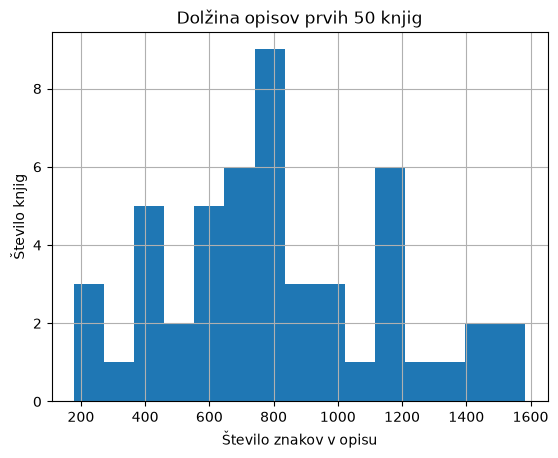

In [27]:
import matplotlib.pyplot as plt

dodatne_knjige["dolzina_opisa"].hist(
    bins=15
)

plt.title(
    "Dolžina opisov prvih 50 knjig"
)

plt.xlabel(
    "Število znakov v opisu"
)

plt.ylabel(
    "Število knjig"
)

plt.show()

In [28]:
najdaljsi_opisi = dodatne_knjige.sort_values(
    by="dolzina_opisa",
    ascending=False
)


najdaljsi_opisi[
    [
        "naslov",
        "avtor",
        "dolzina_opisa"
    ]
].head(10)

,naslov,avtor,dolzina_opisa
13,Wuthering Heights,Emily Brontë,1583
40,And Then There Were None,Agatha Christie,1551
43,Slaughterhouse-Five,Kurt Vonnegut Jr.,1456
19,The Catcher in the Rye,J.D. Salinger,1400
33,Catch-22,Joseph Heller,1378
41,The Master and Margarita,Mikhail Bulgakov,1266
21,The Chronicles of Narnia (The Chronicles of Na...,C.S. Lewis,1157
24,"Little Women (Little Women, #1)",Louisa May Alcott,1150
14,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,1148
26,The Grapes of Wrath,John Steinbeck,1142
